# Análise de Dados

## Importações

In [30]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

## Medições Brutas de Diâmetro (cm)

In [18]:
measurement_data = {
  'm1':  [0.71, 0.57, 0.58, 0.73, 0.59, 0.70, 0.60],
  'm2':  [0.71, 1.03, 0.89, 0.91, 1.00, 0.92, 1.01],
  'm4':  [1.17, 1.18, 1.30, 1.17, 1.01, 1.25, 1.19],
  'm8':  [1.52, 1.21, 1.49, 1.21, 1.09, 1.45, 1.29],
  'm16': [1.95, 2.11, 2.02, 1.95, 1.92, 2.29, 1.80],
  'm32': [2.81, 2.57, 2.44, 2.86, 2.59, 2.51, 3.12],
  'm64': [3.03, 3.97, 3.80, 2.17, 3.92, 2.78, 3.07],
}

measurement_dataframe = pd.DataFrame(measurement_data).T
measurement_dataframe.columns = [f"med_{i+1}" for i in range(7)]
measurement_dataframe.index.name = "amostra"
measurement_dataframe.to_csv("measurement_data.csv")
measurement_dataframe

,med_1,med_2,med_3,med_4,med_5,med_6,med_7
amostra,,,,,,,
m1,0.71,0.57,0.58,0.73,0.59,0.70,0.60
m2,0.71,1.03,0.89,0.91,1.00,0.92,1.01
m4,1.17,1.18,1.30,1.17,1.01,1.25,1.19
m8,1.52,1.21,1.49,1.21,1.09,1.45,1.29
m16,1.95,2.11,2.02,1.95,1.92,2.29,1.80
m32,2.81,2.57,2.44,2.86,2.59,2.51,3.12
m64,3.03,3.97,3.80,2.17,3.92,2.78,3.07


## Análise Estatística das Medições de Diâmetro 

- Média Aritmética
- Desvio Padrão Amostral
- Erro Padrão da Média

In [40]:
reading_measurement_data = pd.read_csv("measurement_data.csv", index_col="amostra")

def sem(series: pd.Series) -> float:
    return series.std(ddof=1) / np.sqrt(len(series))

stats = reading_measurement_data.agg(["mean", "std", sem], axis=1)

stats.columns = ["Média (cm)", "Desvio Padrão (cm)", "Erro Padrão (cm)"]
stats.index.name = "Amostra"

stats.to_csv("measurement_stats.csv")
stats

,Média (cm),Desvio Padrão (cm),Erro Padrão (cm)
Amostra,,,
m1,0.640000,0.069761,0.026367
m2,0.924286,0.109218,0.041281
m4,1.181429,0.089894,0.033977
m8,1.322857,0.165198,0.062439
m16,2.005714,0.156935,0.059316
m32,2.700000,0.240416,0.090869
m64,3.248571,0.675510,0.255319


### Gráfico D (Diâmetro) vs M (Massa) - Linear

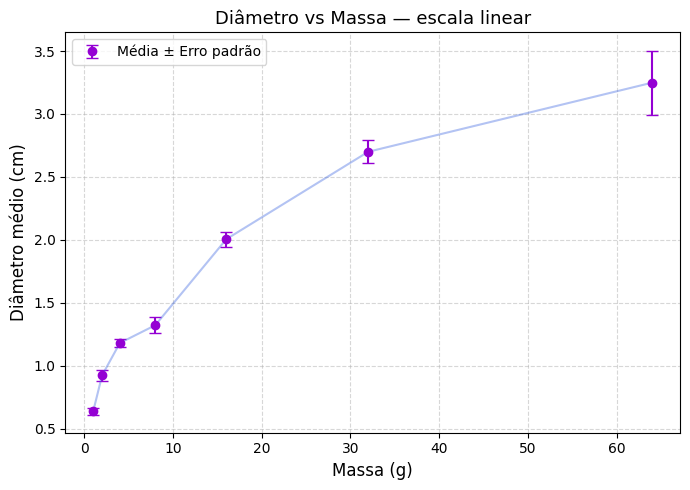

In [36]:
masses = [1, 2, 4, 8, 16, 32, 64]
avarages  = stats["Média (cm)"].values
errors   = stats["Erro Padrão (cm)"].values

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    masses, avarages,
    yerr=errors,
    fmt='o',               
    capsize=4,            
    color='darkviolet',
    label='Média ± Erro padrão'
)

ax.plot(masses, avarages, '-', color='royalblue', alpha=0.4)

ax.set_xlabel("Massa (g)", fontsize=12)
ax.set_ylabel("Diâmetro médio (cm)", fontsize=12)
ax.set_title("Diâmetro vs Massa — escala linear", fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Gráfico ln(D) vs ln(M) com regressão

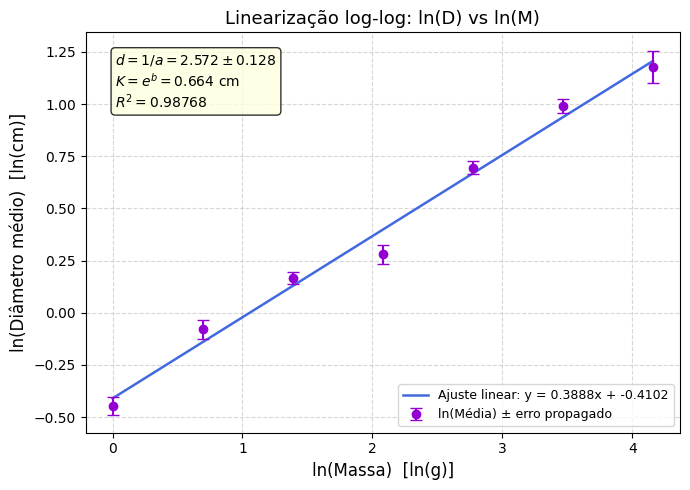

In [38]:
masses = np.array([1, 2, 4, 8, 16, 32, 64])
avarages  = stats["Média (cm)"].values
errors   = stats["Erro Padrão (cm)"].values

ln_M = np.log(masses)
ln_D = np.log(avarages)

ln_D_err = errors / avarages

slope, intercept, r_value, p_value, stderr = scipy.stats.linregress(ln_M, ln_D)

d = 1 / slope
K = np.exp(intercept)

sigma_d = stderr / slope**2

x_fit = np.linspace(ln_M.min(), ln_M.max(), 200)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    ln_M, ln_D,
    yerr=ln_D_err,
    fmt='o',
    capsize=4,
    color='darkviolet',
    label='ln(Média) ± erro propagado',
    zorder=3
)

ax.plot(
    x_fit, y_fit,
    '-', color='royalblue', linewidth=1.8,
    label=f'Ajuste linear: y = {slope:.4f}x + {intercept:.4f}'
)

textstr = (
    f'$d = 1/a = {d:.3f} \\pm {sigma_d:.3f}$\n'
    f'$K = e^b = {K:.3f}$ cm\n'
    f'$R^2 = {r_value**2:.5f}$'
)
ax.text(
    0.05, 0.95, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax.set_xlabel("ln(Massa)  [ln(g)]", fontsize=12)
ax.set_ylabel("ln(Diâmetro médio)  [ln(cm)]", fontsize=12)
ax.set_title("Linearização log-log: ln(D) vs ln(M)", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()